In [7]:
import pandas as pd
import numpy as np

In [8]:
df=pd.read_csv("C:\\Users\\jojic\\OneDrive\\Desktop\\mljourney\\gui-building\\drug_type\\drug_prediction.csv")

In [9]:
df.isnull().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

In [10]:
df[df.duplicated].shape

(0, 6)

In [11]:
df["Sex"]=df["Sex"].map({"F":0,"M":1})
df["BP"]=df["BP"].map({'HIGH':0, 'LOW':1, 'NORMAL':2})
df["Cholesterol"]=df["Cholesterol"].map({'HIGH':0, 'LOW':1, 'NORMAL':2})

<Axes: >

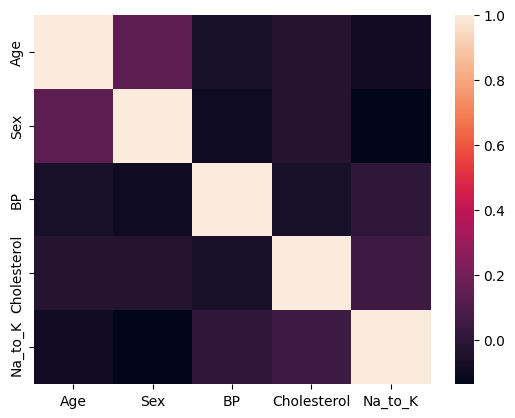

In [12]:
import seaborn as sns
col=["Age","Sex","BP","Cholesterol","Na_to_K"]
sns.heatmap(df[col].corr())

In [13]:
x=df.iloc[:,:-1] 
y=df.iloc[:,-1]
x.head()

,Age,Sex,BP,Cholesterol,Na_to_K
0,23.0,0,0,0,25.355
1,47.0,1,1,0,13.093
2,47.0,1,1,0,10.114
3,28.0,0,2,0,7.798
4,61.0,0,1,0,18.043


In [14]:
df["Drug"].value_counts()

Drug
DrugY    237
drugX    200
drugA    168
drugC    161
drugB    161
Name: count, dtype: int64

In [15]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)

In [16]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

In [17]:
from imblearn.over_sampling import SMOTE
sm=SMOTE(random_state=42)
x_train_smote,y_train_smote = sm.fit_resample(x_train,y_train)

In [18]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_smote=scaler.fit_transform(x_train_smote)
x_test=scaler.transform(x_test) 

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,f1_score
knn = KNeighborsClassifier()
knn.fit(x_train_smote,y_train_smote)
y_pred = knn.predict(x_test)
print("accuracy_score",accuracy_score(y_test,y_pred)*100) 
print("f1_score",f1_score(y_test,y_pred,average="macro")*100) 

accuracy_score 88.17204301075269
f1_score 88.06311335723102


In [20]:
params = {
    "n_neighbors":[3,5,7,9],
    "weights":["uniform","distance"],
    "algorithm":["auto","ball_tree","kd_tree","brute"]
}

In [21]:
from sklearn.model_selection import GridSearchCV
gs = GridSearchCV(knn,params,cv=10)
gs.fit(x_train_smote,y_train_smote)
gs.best_params_

{'algorithm': 'auto', 'n_neighbors': 5, 'weights': 'distance'}

In [22]:
knn = KNeighborsClassifier(algorithm="auto",n_neighbors=5,weights="distance")
knn.fit(x_train_smote,y_train_smote)
y_pred = knn.predict(x_test)
print("accuracy_score",accuracy_score(y_test,y_pred)*100) 
print("f1_score",f1_score(y_test,y_pred,average="macro")*100) 

accuracy_score 89.78494623655914
f1_score 89.54673008908183


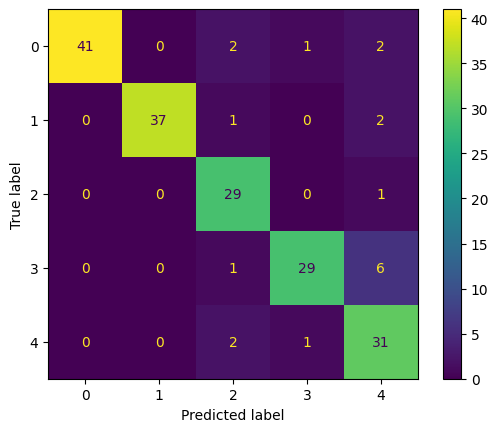

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test,y_pred) 

In [ ]:
import joblib
joblib.dump(knn,"dt_model.pkl")
joblib.dump(scaler,"scaler.pkl") 

['scaler.pkl']